# Implementing simple chatbot using langgraph

In [22]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START,END

## Reducers 
from typing import Annotated
from langgraph.graph.message import add_messages

In [23]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [24]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [25]:
from langchain_groq import ChatGroq
llm_groq= ChatGroq(model="llama-3.3-70b-versatile")
llm_groq.invoke("Hello I am shivansh")

AIMessage(content="Hello Shivansh, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 42, 'total_tokens': 70, 'completion_time': 0.04476959, 'completion_tokens_details': None, 'prompt_time': 0.004225356, 'prompt_tokens_details': None, 'queue_time': 0.512633391, 'total_time': 0.048994946}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f2361-99f4-7de0-b66c-397c77695ee0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 42, 'output_tokens': 28, 'total_tokens': 70})

In [26]:
## We will start creating nodes

from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
def superbot(state:State):
    return {"messages":[llm_groq.invoke(state['messages'])]}


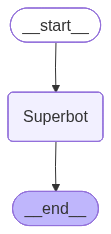

In [27]:
graph = StateGraph(State)

##node
graph.add_node("Superbot",superbot)

##Edges
graph.add_edge(START,"Superbot")
graph.add_edge("Superbot",END)

graph_builder = graph.compile(checkpointer=memory)

## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))


In [29]:
## Invocation
config = {"configurable":{"thread_id":"1"}}
graph_builder.invoke({'messages':"Hi, My name is shivansh and i like cricker"},config)


{'messages': [HumanMessage(content='Hi, My name is shivansh and i like cricker', additional_kwargs={}, response_metadata={}, id='ee3110fb-3fa8-48fd-89e3-0c7ba1bc880e'),
  AIMessage(content="Nice to meet you, Shivansh! Cricket is an amazing sport, and I'm sure you must be excited about the thrill and action it brings. Who's your favorite cricketer or team? Do you play cricket yourself or enjoy watching it?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 49, 'total_tokens': 101, 'completion_time': 0.203269438, 'completion_tokens_details': None, 'prompt_time': 0.005940516, 'prompt_tokens_details': None, 'queue_time': 0.351151372, 'total_time': 0.209209954}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f2362-464f-7633-a4b7-4ff51d8cb538-0', tool_calls=[], invalid_tool_calls=[], usage_metadata

## Streaming

##Streaming the response with stream method

In [32]:
#Create a thread
config = {"configurable":{"thread_id":"2"}}

for chunk in graph_builder.stream({'messages':"Hi, My name is shivansh and i like cricker"},config,stream_mode="updates"):
    print(chunk)
    

{'Superbot': {'messages': [AIMessage(content="Nice to meet you, Shivansh! Cricket is an exciting sport, isn't it? Which team or player is your favorite? Do you have a favorite format of the game, like Test cricket, ODIs, or T20s?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 49, 'total_tokens': 99, 'completion_time': 0.160629284, 'completion_tokens_details': None, 'prompt_time': 0.002393934, 'prompt_tokens_details': None, 'queue_time': 0.647408152, 'total_time': 0.163023218}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ba38bbab80', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f2371-675c-78a0-8413-7d9efe0a77d4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 49, 'output_tokens': 50, 'total_tokens': 99})]}}


In [34]:
for chunk in graph_builder.stream({'messages':"Hi, My name is shivansh and i like cricker"},config,stream_mode="values"):
    print(chunk)
    

{'messages': [HumanMessage(content='Hi, My name is shivansh and i like cricker', additional_kwargs={}, response_metadata={}, id='93de7178-7f4b-458e-afba-0f8aca8f2aab'), AIMessage(content="Nice to meet you, Shivansh! Cricket is an exciting sport, isn't it? Which team or player is your favorite? Do you have a favorite format of the game, like Test cricket, ODIs, or T20s?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 49, 'total_tokens': 99, 'completion_time': 0.160629284, 'completion_tokens_details': None, 'prompt_time': 0.002393934, 'prompt_tokens_details': None, 'queue_time': 0.647408152, 'total_time': 0.163023218}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ba38bbab80', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f2371-675c-78a0-8413-7d9efe0a77d4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 49, 'output_tokens':

## Streaming with async method

In [37]:
config = {"configurable":{"thread_id":"3"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is shivansh and i like coding"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is shivansh and i like coding']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019f23be-e9ba-7be3-8b4c-475c8263faf6', 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is shivansh and i like coding', additional_kwargs={}, response_metadata={}, id='b116b94e-a4b0-45be-8b13-42d79789f175')]}}, 'name': 'Superbot', 'tags': ['graph:step:1'], 'run_id': '019f23be-e9bd-7f11-b315-a41ba97c3ccf', 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'Superbot', 'langgraph_triggers': ('branch:to:Superbot',), 'langgraph_path': ('__pregel_pull', 'Superbot'), 'langgraph_checkpoint_ns': 'Superbot:f1a5cea8-ea9a-4b9c-5bd7-8ac8a5b00fb7'}, 'parent_ids': ['019f23be-e9ba-7be3-8b4c-475c8263faf6']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMess